<a href="https://colab.research.google.com/github/Kamrul785/Machine-Learning-Engineer-Task/blob/main/Level2_Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("/content/churn-bigml-80.csv")
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [ ]:
df.shape

(2666, 20)

In [ ]:
df.nunique()

,0
State,51
Account length,205
Area code,3
International plan,2
Voice mail plan,2
Number vmail messages,42
Total day minutes,1489
Total day calls,115
Total day charge,1489
Total eve minutes,1442


In [ ]:
train_df = pd.read_csv('/content/churn-bigml-80.csv')
test_df = pd.read_csv('/content/churn-bigml-20.csv')

In [ ]:
def preprocess_data(df):

    df = df.drop(columns=['State']) #state feature doesn't have better relation with target column

    binary_map = {'Yes': 1, 'No': 0}
    df['International plan'] = df['International plan'].map(binary_map)
    df['Voice mail plan'] = df['Voice mail plan'].map(binary_map)

    # 'Charge' columns as they are perfectly correlated with 'Minutes'
    charge_cols = ['Total day charge', 'Total eve charge', 'Total night charge', 'Total intl charge']
    df = df.drop(columns=charge_cols)

    # convert Churn to integer type
    df['Churn'] = df['Churn'].astype(int)
    return df

In [ ]:
# Apply preprocessing
train_clean = preprocess_data(train_df)
test_clean = preprocess_data(test_df)

In [ ]:
# 3. Split into features and target
X_train = train_clean.drop(columns=['Churn'])
y_train = train_clean['Churn']
X_test = test_clean.drop(columns=['Churn'])
y_test = test_clean['Churn']

In [ ]:
# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")
display(train_clean.head())

Training features shape: (2666, 14)
Testing features shape: (667, 14)


,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,128,415,0,1,25,265.1,110,197.4,99,244.7,91,10.0,3,1,0
1,107,415,0,1,26,161.6,123,195.5,103,254.4,103,13.7,3,1,0
2,137,415,0,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0,0
3,84,408,1,0,0,299.4,71,61.9,88,196.9,89,6.6,7,2,0
4,75,415,1,0,0,166.7,113,148.3,122,186.9,121,10.1,3,3,0


Logistic Regression Performance (Balanced Class Weights):
              precision    recall  f1-score   support

           0       0.95      0.78      0.86       572
           1       0.36      0.76      0.49        95

    accuracy                           0.78       667
   macro avg       0.66      0.77      0.67       667
weighted avg       0.87      0.78      0.80       667



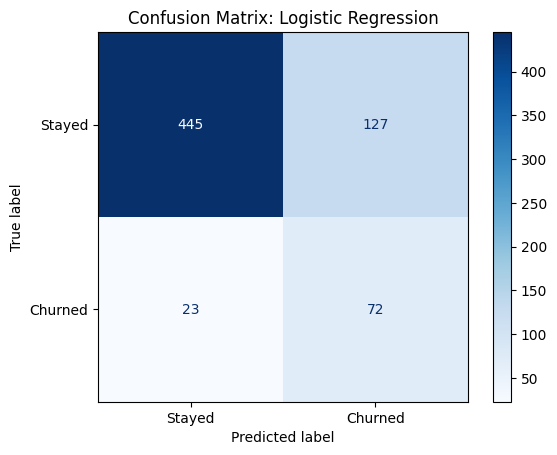

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)

print("Logistic Regression Performance (Balanced Class Weights):")
print(classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay.from_estimator(
    log_reg,
    X_test_scaled,
    y_test,
    display_labels=['Stayed', 'Churned'],
    cmap='Blues'
)
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

# Model Interpretations

In [ ]:

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
})
coefficients['Odds Ratio'] = np.exp(coefficients['Coefficient'])

print("Top Features Influencing Churn (Highest Odds Ratios):")
display(coefficients.sort_values(by='Odds Ratio', ascending=False).head())

print("\nTop Features Reducing Churn (Lowest Odds Ratios):")
display(coefficients.sort_values(by='Odds Ratio', ascending=True).head())

Top Features Influencing Churn (Highest Odds Ratios):


,Feature,Coefficient,Odds Ratio
13,Customer service calls,0.758303,2.134650
2,International plan,0.724278,2.063240
5,Total day minutes,0.664706,1.943918
4,Number vmail messages,0.497369,1.644390
7,Total eve minutes,0.275126,1.316697



Top Features Reducing Churn (Lowest Odds Ratios):


,Feature,Coefficient,Odds Ratio
3,Voice mail plan,-0.842101,0.430805
12,Total intl calls,-0.209583,0.810922
1,Area code,-0.031072,0.969406
8,Total eve calls,0.006505,1.006526
10,Total night calls,0.012607,1.012687


### Evaluation

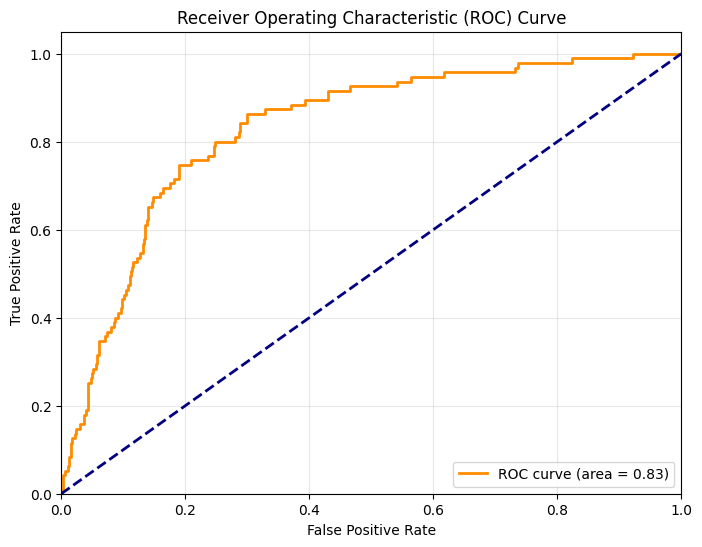

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()